In [1]:
from shutil import rmtree
from pathlib import Path

import matplotlib.pyplot as plt

from vot_utils.data import DATA_DIRECTORY

In [204]:
import torch

from torch import is_tensor
from torch import tensor
from torch.nn import Module
from torch.utils.data import Dataset, DataLoader

from adam_atan2_pytorch import MuonAdamAtan2

from einops import rearrange

import torchvision
import torchvision.transforms as T
from torchvision.utils import save_image

# from transfusion_pytorch import Transfusion, print_modality_sample
# from accelerate import Accelerator


In [217]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

In [3]:
# functions

def divisible_by(num, den):
    return (num % den) == 0


In [4]:
class Encoder(Module):
    def forward(self, x):
        x = rearrange(x, '... 1 (h p1) (w p2) -> ... h w (p1 p2)', p1 = 2, p2 = 2)
        return x * 2 - 1

class Decoder(Module):
    def forward(self, x):
        x = rearrange(x, '... h w (p1 p2) -> ... 1 (h p1) (w p2)', p1 = 2, p2 = 2, h = 14)
        return ((x + 1) * 0.5).clamp(min = 0., max = 1.)


In [5]:
class MnistDataset(Dataset):
    def __init__(self, download=False):
        self.mnist = torchvision.datasets.MNIST(
            DATA_DIRECTORY,
            download=download
        )
    
    def __len__(self):
        return len(self.mnist)
    
    def __getitem__(self, idx):
        pil, labels = self.mnist[idx]
        digit_tensor = T.PILToTensor()(pil)
        return (digit_tensor / 255).float()
    
def cycle(iter_dl):
    while True:
        for batch in iter_dl:
            yield batch

In [6]:
dataset = MnistDataset()
dataloader = DataLoader(dataset, batch_size = 32, shuffle = True)

iter_dl = cycle(dataloader)

In [7]:
# optimizer = MuonAdamAtan2(model.muon_parameters(), model.parameters(), lr = 8e-4)

# accelerator = Accelerator()

# model, optimizer, dataloader = accelerator.prepare(model, optimizer, dataloader)

# ema_model.to(accelerator.device)


In [268]:
def plot_batch(batch):
    # Fetch a single batch of 32 images from your infinite iterator
    images = batch

    # Create a grid to display them neatly (e.g., 8 images per row)
    grid_img = torchvision.utils.make_grid(images, nrow=8)

    # PyTorch image tensors are (Channels, Height, Width).
    # Matplotlib expects (Height, Width, Channels), so we permute the dimensions.
    grid_img_np = grid_img.permute(1, 2, 0).numpy()

    # Plot the grid
    plt.figure(figsize=(10, 5))
    plt.imshow(grid_img_np, cmap='gray')
    plt.axis('off')
    plt.title("Sample MNIST Batch")
    plt.show()

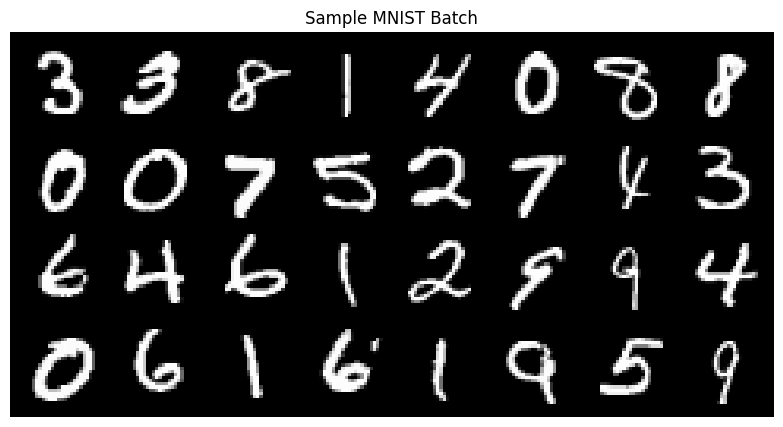

In [269]:
plot_batch(next(iter_dl))

#### Manual Run

In [418]:
from functools import partial

from references.transfusion_pytorch.transfusion_pytorch.transfusion import (
    Transformer,
    default,
    exists,
    cast_tuple,
    default_to_modality_shape_fn,
    identity,
    add_temp_batch_dim,
    char_tokenize,
    decode_chars,
    append_dims,
    ModalityInfo,
    get_model_output_to_flow_fn,
    pack_one_with_inverse
)

import torch.nn.functional as F

from torch import nn
from torch.nn import ModuleList
from torch.nn import Linear

from axial_positional_embedding import ContinuousAxialPositionalEmbedding
from rotary_embedding_torch import RotaryEmbedding, apply_rotary_emb
from torchdiffeq import odeint
from ema_pytorch import EMA

from beartype import beartype
from beartype.door import is_bearable

In [367]:
batch = next(iter_dl)

In [ ]:
num_text_tokens = 10
dim_latent = 4
channel_first_latent = False
modality_default_shape = (14, 14)
modality_encoder = Encoder()
modality_decoder = Decoder()
add_pos_emb = True
modality_num_dim = 2

velocity_consistency_loss_weight = 0.1
reconstruction_loss_weight = 0.1
model_output_clean = True
transformer = dict(dim=64, depth=4, dim_head=32, heads=8, attn_laser=True)

to_modality_shape_fn = default_to_modality_shape_fn
fallback_to_default_shape_if_invalid = False
modality_encoder_decoder_requires_batch_dim = True
pre_post_transformer_enc_dec = None

ignore_index = -1
flow_loss_weight = 1.
text_loss_weight = 1.

odeint_kwargs = dict(
    atol = 1e-5,
    rtol = 1e-5,
    method = 'midpoint'
)
eps = 1e-2
prob_uncond = 0.1

In [ ]:
class Transfusion(nn.Module):

    def __init__(
        self,
        num_text_tokens,
        transformer,
        dim_latent=None,
        model_output_clean=True,
        channel_first_latent=False,
        modality_default_shape=None,
        modality_encoder=None,
        modality_decoder=None,
        add_pos_emb=False,
        modality_num_dim=None,
        velocity_consistency_loss_weight=0.1,
        reconstruction_loss_weight=0,
        to_modality_shape_fn=default_to_modality_shape_fn,
        fallback_to_default_shape_if_invalid=False,
        modality_encoder_decoder_requires_batch_dim=True,
        pre_post_transformer_enc_dec=None,
        ignore_index=-1,
        flow_loss_weight=1.0,
        text_loss_weight=1.0,
        odeint_kwargs=dict(atol=1e-5, rtol=1e-5, method="midpoint"),
        eps=1e-2,
        prob_uncond=0.1,
    ):
        super().__init__()

        if isinstance(transformer, dict):
            transformer = Transformer(**transformer).to(device)

        self.transformer = transformer

        dim = transformer.dim
        dim_latent = default(dim_latent, dim)

In [368]:
# model = Transfusion(...)

In [370]:
if isinstance(transformer, dict):
    transformer = Transformer(**transformer).to(device)

dim = transformer.dim
dim_latent = default(dim_latent, dim)

In [371]:
dim_latents = cast_tuple(dim_latent)
num_modalities = len(dim_latents)
channel_first_latent = cast_tuple(channel_first_latent, num_modalities)
to_modality_shape_fn = cast_tuple(to_modality_shape_fn, num_modalities)

if not exists(modality_default_shape) or is_bearable(modality_default_shape, tuple[int, ...]):
    modality_default_shape = (modality_default_shape,) * num_modalities

modality_num_dim = cast_tuple(modality_num_dim, num_modalities)
add_pos_emb = cast_tuple(add_pos_emb, num_modalities)


In [372]:
pos_emb_mlp = ModuleList([])

for modality_add_pos_emb, modality_ndim in zip(add_pos_emb, modality_num_dim):
    if not modality_add_pos_emb:
        pos_emb_mlp.append(None)
        continue

    pos_generating_mlp = ContinuousAxialPositionalEmbedding(
        dim = dim,
        num_axial_dims = modality_ndim,
    )

    pos_emb_mlp.append(pos_generating_mlp)


modality_encoder = cast_tuple(modality_encoder, 1 if exists(modality_encoder) else num_modalities)
modality_decoder = cast_tuple(modality_decoder, 1 if exists(modality_decoder) else num_modalities)

modality_encoder = ModuleList(modality_encoder)
modality_decoder = ModuleList(modality_decoder)

maybe_add_temp_batch_dim = add_temp_batch_dim if modality_encoder_decoder_requires_batch_dim else identity

In [373]:
num_text_special_ids = 3
sos_id, eos_id, null_text_id = (
    num_text_tokens,
    (num_text_tokens + 1),
    (num_text_tokens + 2),
)

num_modality_special_ids = num_modalities * 2
som_eom_tensor = torch.arange(num_modality_special_ids) + num_text_tokens + num_text_special_ids
som_eom_tensor = rearrange(som_eom_tensor, '(start_end m) -> start_end m', start_end = 2)
som_ids, eom_ids = som_eom_tensor.tolist()

meta_token_offset = num_text_tokens + num_text_special_ids + num_modality_special_ids
meta_id = meta_token_offset
num_meta_tokens = 128 + 1

char_tokenizer = partial(char_tokenize, offset = meta_token_offset + 1)
decode_chars = partial(decode_chars, offset = meta_token_offset + 1)


In [374]:
pre_post_transformer_enc_dec = cast_tuple(pre_post_transformer_enc_dec, num_modalities)

In [375]:
latent_to_model_projs = []
model_to_latent_projs = []

for (
    dim_latent,
    one_channel_first_latent,
    enc_dec,
) in zip(dim_latents, channel_first_latent, pre_post_transformer_enc_dec):
    pre_attend_enc, post_attend_dec = default(enc_dec, (None, None))

    latent_to_model_proj = Linear(dim_latent, dim) if dim_latent != dim else nn.Identity()
    model_to_latent_proj = Linear(dim, dim_latent, bias = False)

    latent_to_model_projs.append(default(pre_attend_enc, latent_to_model_proj))
    model_to_latent_projs.append(default(post_attend_dec, model_to_latent_proj))

latent_to_model_projs = ModuleList(latent_to_model_projs)
model_to_latent_projs = ModuleList(model_to_latent_projs)


In [376]:
rotary_emb = RotaryEmbedding(transformer.dim_head)

effective_num_text_tokens = num_text_tokens + num_text_special_ids + num_modality_special_ids + num_meta_tokens

text_embed = nn.Embedding(effective_num_text_tokens, dim)
to_text_logits = Linear(dim, effective_num_text_tokens, bias = False)
text_only_mask = torch.arange(effective_num_text_tokens) < num_text_tokens

In [377]:
has_recon_loss = reconstruction_loss_weight > 0.
odeint_fn = partial(odeint, **odeint_kwargs)

#### Run Forward Pass (Modality Only)

In [448]:
batch = next(iter_dl)
# loss = model(batch, velocity_consistency_ema_model = ema_model)


In [449]:
modalities = batch
velocity_consistency_ema_model = None
decoding_text_or_modality = None
return_embed = False
return_loss = True
modality_type = None
times = None

In [450]:
is_decoding = exists(decoding_text_or_modality)
is_text_only = is_tensor(modalities) and modalities.dtype in (torch.int, torch.long)
is_modality_only = is_tensor(modalities) and modalities.dtype == torch.float

In [451]:
modalities = modalities.to(device)
orig_modalities = modalities

modality_type = default(modality_type, 0)

mod = ModalityInfo(
    encoder = modality_encoder[modality_type],
    decoder = modality_decoder[modality_type],
    latent_to_model = latent_to_model_projs[modality_type].to(device),
    model_to_latent = model_to_latent_projs[modality_type].to(device),
    add_pos_emb = add_pos_emb[modality_type],
    pos_emb_mlp = pos_emb_mlp[modality_type].to(device),
    num_dim = modality_num_dim[modality_type],
    dim_latent = dim_latents[modality_type],
    default_shape = modality_default_shape[modality_type],
    som_id = som_ids[modality_type],
    eom_id = eom_ids[modality_type],
    to_shape_fn = to_modality_shape_fn[modality_type],
    channel_first_latent = channel_first_latent[modality_type],
    modality_type = modality_type
)

In [452]:
encode_modality = True

if encode_modality and exists(mod.encoder):
    with torch.no_grad():
        mod.encoder.eval()
        modalities = mod.encoder(modalities).detach()

tokens = modalities
batch, device = tokens.shape[0], tokens.device

In [453]:
if not exists(times):
    times = torch.rand((batch,), device = device)

padded_times = append_dims(times, tokens.ndim - 1)
noise = torch.randn_like(tokens)
noised_tokens = padded_times * tokens + (1. - padded_times) * noise
flow = tokens - noise

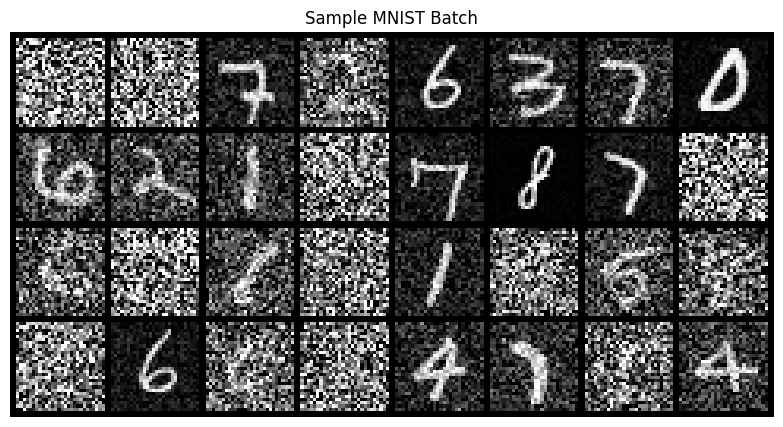

In [454]:
plot_batch(mod.decoder(noised_tokens).cpu())


In [455]:
# plot_batch(mod.decoder(tokens.cpu()))
# plot_batch(mod.decoder(noised_tokens.cpu()))


In [456]:
model_output_to_flow = (
    get_model_output_to_flow_fn(noised_tokens, times, eps)
    if model_output_clean
    else identity
)

noised_tokens = mod.latent_to_model(noised_tokens)

In [459]:
if mod.add_pos_emb:
    _, *axial_dims, _ = noised_tokens.shape

noised_tokens, inverse_pack_axial_dims = pack_one_with_inverse(noised_tokens, 'b * d')

if mod.add_pos_emb:
    axial_pos_emb = mod.pos_emb_mlp(tensor(axial_dims), flatten = True)
    noised_tokens = noised_tokens + axial_pos_emb

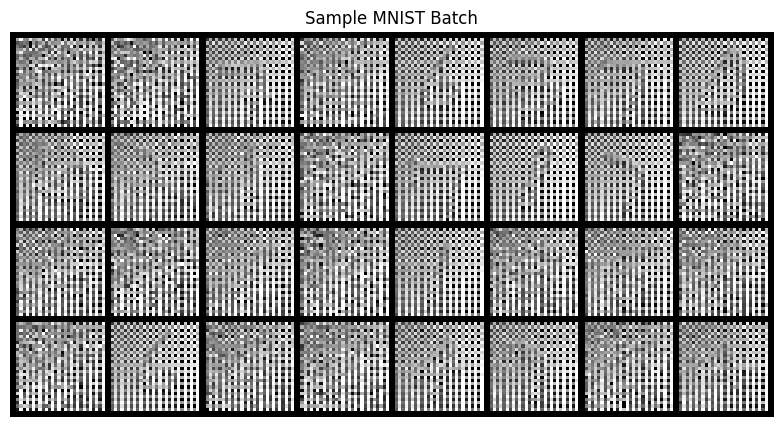

In [460]:
plot_batch(mod.decoder(mod.model_to_latent(inverse_pack_axial_dims(noised_tokens))).cpu())


In [461]:
embed = transformer(
    noised_tokens,
    times = times,
    modality_only = True,
)

embed = inverse_pack_axial_dims(embed)
model_output = mod.model_to_latent(embed)
pred_flow = model_output_to_flow(model_output)

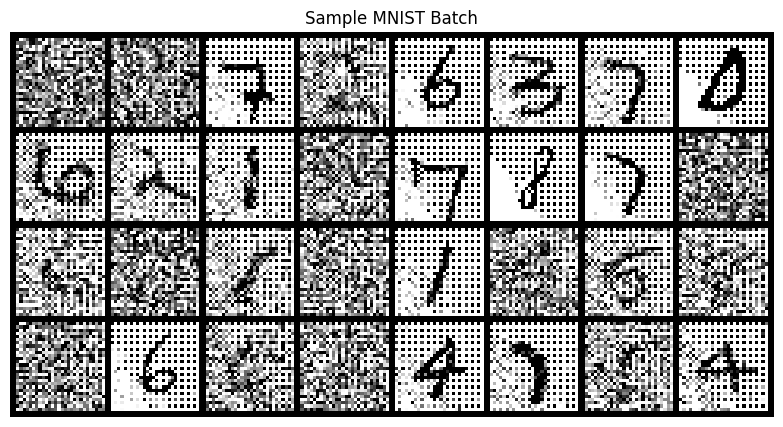

In [463]:
plot_batch(mod.decoder(pred_flow).cpu())

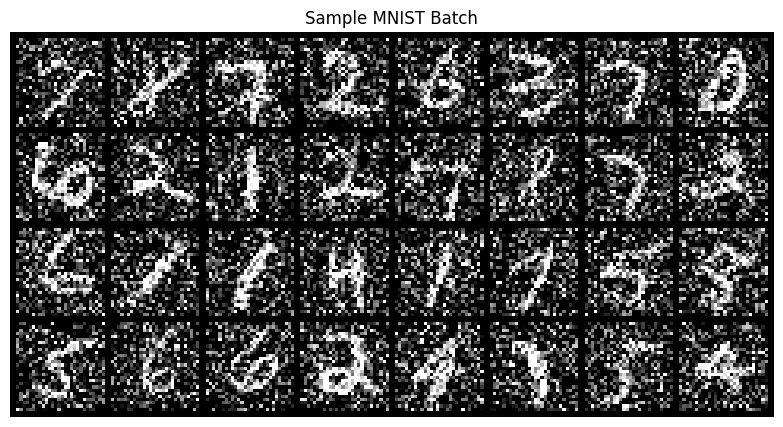

In [464]:
plot_batch(mod.decoder(flow).cpu())


In [470]:
flow_loss = F.mse_loss(pred_flow, flow)

if has_recon_loss:
    recon = noise + pred_flow * (1. - padded_times)

    if exists(mod.decoder):
        with torch.no_grad():
            mod.decoder.eval()
            recon = mod.decoder(recon)

    recon_loss = F.mse_loss(
        recon,
        orig_modalities
    )

In [471]:
total_loss = (
    flow_loss +
    recon_loss * reconstruction_loss_weight
)

In [473]:
# TODO: 
# 1. Put everything together into a custom Image only Transfusion model
# 2. Run training loop